## Example notebook
### Working with Krill Fishery Acoustics in ODP workspaces
This notebook was originally provided by Dominik Bahlburg (AWI) and Sebastian Menze (IMR), and has been modified by Gustav Kågesten (HUB Ocean) to make the most of ODP workspaces. Updated 2026-02-10

The notebook provide an example how raw sonar files can be converted to standard netcdf format for visualisation and further processing 

### Data collection
This notebook is using data from the Aker QRILL Company which can be found on the Ocean Data Platform here:
https://app.hubocean.earth/catalog/collection/7c61c869-a7c1-4f1c-900e-34636ee3392a

### Introduction
The acoustic data from the krill fishery were recorded using EK60 and ES80 echosounders from Kongsberg Maritime. The files are available in the ".raw" format, which is difficult to handle with common Python tools and packages. Therefore, the first step is to convert the .raw files into NetCDF files, which are much easier to handle. We use the KrillScan package, which integrates pyEcholab tools, to read and process the .raw files.
You may come across old acoustic files which cannot be converted using the pyEcholab tools.

### Import Packages

In [11]:
%pip install -U krillscan --quiet

Note: you may need to restart the kernel to use updated packages.


In [128]:
# --- Acoustic data / KrillScan ---
import krillscan
from krillscan.echolab2.instruments import EK80, EK60

# --- Data handling ---
import pandas as pd
import numpy as np
import xarray as xr

# --- Geospatial ---
import geopandas as gpd
from shapely import wkt

# --- Image / array processing ---
from skimage.transform import resize

# --- File system & config ---
from pathlib import Path
import os
import json
import tempfile

# --- Ocean Data Platform ---
from odp.client import Client

### Connect to ODP

In [129]:
# --- Connect to Ocean Data Platform ---
# If running outside an ODP workspace, supply your API key:
# cli = Client(api_key='your_api_key')
#cli = Client()

# --- Select dataset (Antarctic Sea 2021) ---
QRILL_DATASET_ID = "db17042e-ef18-4ec9-84be-da33c461dd9e"
dataset = cli.dataset(QRILL_DATASET_ID)

# --- List files in dataset ---
all_files = dataset.files.list()

Next, we will download a single .raw file. This one is from the FV Antarctic Sea, recorded on 16.07.2021. If you are interested in specific locations or time periods you have multiple options, you can filter the "all_files" objects to identify your files of interest, you can plot all tracklines and explore them usíng the JyputerGIS view as shown in this workbook, or you can use the Ocean Data Platform to filter and explore available cruises using the the trackline dataset provided: https://app.hubocean.earth/catalog/dataset/a954a551-4be9-4059-a85a-b3ef8f75e75f/aker-biomarine-tracklines-and-metadata-2011-2025-

### Process file metadata
Convert the file metadata from all acoustic files in the selected dataset into a GeoDataFrame with geometries for spatial filtering and mapping.

In [130]:

def files_to_gdf(files, crs="EPSG:4326"):
    """
    Convert ODP file metadata to a GeoDataFrame with parsed geometries.
    """
    rows = []

    for f in files:
        row = dict(f)  # copy file metadata

        # properties: [['k','v'], ...] -> {'k': 'v', ...}
        props = row.get("properties")
        if isinstance(props, list):
            row["properties"] = {k: v for k, v in props if isinstance(k, str)}
            row.update(row["properties"])  # flatten properties

        # geometry: WKT string -> Shapely geometry
        geom = row.get("geometry")
        row["geometry"] = wkt.loads(geom) if isinstance(geom, str) and geom else None

        rows.append(row)

    gdf = gpd.GeoDataFrame(
        pd.DataFrame(rows),
        geometry="geometry",
        crs=crs,
    )

    # drop files without geometry
    return gdf[gdf.geometry.notna()].copy()


# --- usage ---
gdf = files_to_gdf(all_files)
# print(gdf.head())
# print(gdf.crs)


### JupyterGIS view
Initialize a JupyterGIS map side-window and add ESRI world imagery basemap for visualizing file geometries.

In [131]:
from jupytergis import GISDocument

# Create a new JupyterGIS document (map canvas)
gis_doc = GISDocument()

# Add a basemap layer (ESRI World Imagery)
gis_doc.add_raster_layer(
    "https://services.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    name="ESRI World Imagery"
)

# Display the interactive map in a sidecar panel
gis_doc.sidecar(title="All files geometry map")

Add the file geometries as a GeoJSON vector layer to display survey tracklines on the map. Now you can explore the trackline data in the GIS window.

In [136]:
# Add file geometries (tracklines) to the map as a GeoJSON layer
gis_doc.add_geojson_layer(
    data=json.loads(gdf.to_json()),
    name="tracklines"
)

'f59ea47c-c390-445a-8bbc-9b10e58022d4'

### Load raw acoustic file
Next, we will load a single .raw file from ODP to your workspace. This one is from the FV Antarctic Sea, recorded on 16.07.2021. If you are interested in specific locations or time periods, you can (1) filter the "all_files" objects to identify your files of interest or, (2)explore the tracklines plotted using jupyterGIS view above, or (3) use the Ocean Data Platform as to filter and explore available cruises using the the trackline dataset provided 

https://app.hubocean.earth/catalog/dataset/a954a551-4be9-4059-a85a-b3ef8f75e75f/aker-biomarine-tracklines-and-metadata-2011-2025-

In [137]:
# Select target raw acoustic file by filename
target = "AKBM-AntarcticSea-2021-D20210716-T221336.raw" # main example with bubble trail and krill detections
#target = "AKBM-AntarcticSea-2021-D20210101-T073100.raw" # example file with bottom detection

# Find matching file metadata in the dataset
matched_file = [f for f in all_files if f.get("name") == target]
if not matched_file:
    raise FileNotFoundError(f"Target file not found in dataset: {target}")

# Create a download pointer (file-like stream)
file_pointer = dataset.files.download(matched_file[0]["id"])


This cell downloads a selected raw acoustic file from ODP to a temporary local path and reads it using EK80, falling back to EK60 if needed.

In [133]:
meta = next(f for f in all_files if f.get("name") == target)  # raises if not found

dl = dataset.files.download(meta["id"])

with tempfile.NamedTemporaryFile("w+b", suffix=os.path.splitext(target)[1] or ".raw") as tmp:
    tmp.write(dl.read() if hasattr(dl, "read") else b"".join(dl))
    tmp.flush()

    try:
        raw_obj = EK80.EK80(); raw_obj.read_raw(tmp.name)
        instrument = "EK80"
    except Exception:
        raw_obj = EK60.EK60(); raw_obj.read_raw(tmp.name)
        instrument = "EK60"

print("Read with:", instrument)
print(raw_obj)

Read with: EK80
<class 'krillscan.echolab2.instruments.EK80.EK80'> at 0x7ff20b9ff6e0
    EK80 object contains data from 2 channels:
        GPT 00907206dc91-1 ES38-7 :: power/angle (3223, 5208)
        GPT 0090720734d9-1 ES120-7C :: power/angle (3223, 2604)
    data start time: 2021-07-16T22:13:36.254
      data end time: 2021-07-16T23:07:18.628
    number of pings: 3223



The output tells us that the acoustic file contains 2 channels for the two frequencies and 3223 pings (events at which the echosounder emitted an acoustic signal into the water), recorded from 2021-07-16T22:13:36.254 to 2021-07-16T23:07:18.628. We then extract the recorded data for both frequencies and store it in an Xarray object. During this process, we convert the raw "power signal" stored in the raw file into the Sv (volume backscattering strength) unit, a common format for active acoustics. This unit indicates how much backscatter, or "echo," was recorded at different depths. Typically, a calibration file is needed for this conversion. 
Unfortunately, the fisheries acoustics are not calibrated, so we must assume "standard Southern Ocean conditions" to calibrate the data. Therefore, the data cannot be used to directly estimate krill biomass or density, as these require calibrated acoustics.
During the conversion process, we resample the acoustics to a uniform depth resolution of 0.5 meters and a time resolution of 1 second, and we store the data in a NetCDF file. Additionally, we extract the GPS coordinates to assign the acoustic data to the locations at which it was recorded.

In [107]:
# Inspect environmental assumptions used during processing
f0 = next(iter(raw_obj.frequency_map))
raw_data = raw_obj.raw_data[raw_obj.frequency_map[f0][0]][0]
cal = raw_data.get_calibration()

print("Environmental values used for calibration:")
print(f"  Temperature (°C): {cal.temperature}")
print(f"  Salinity (PSU): {cal.salinity}")
print(f"  Sound speed (m/s): {cal.sound_speed}")
print(f"")
print(f"Values that are constant in time and close to commonly used nominal settings (such as 10 °C, 35 PSU, and 1500 m/s) should be interpreted with caution, as they often indicate default assumptions rather than measured oceanographic conditions.When external temperature–salinity data are available, depth and Sv estimates can be refined accordingly.")


Environmental values used for calibration:
  Temperature (°C): 10.0
  Salinity (PSU): 35.0
  Sound speed (m/s): 1500.0

Values that are constant in time and close to commonly used nominal settings (such as 10 °C, 35 PSU, and 1500 m/s) should be interpreted with caution, as they often indicate default assumptions rather than measured oceanographic conditions.When external temperature–salinity data are available, depth and Sv estimates can be refined accordingly.


### Resample raw file to NetCDF
Extract the first frequency channel, compute calibrated volume backscattering strength (Sv), and resample to a uniform range–time grid. 

In [75]:
from skimage.transform import resize

# Pick first available frequency/channel
f = next(iter(raw_obj.frequency_map))
chan_id = raw_obj.frequency_map[f][0]
raw_data = raw_obj.raw_data[chan_id][0]

# Calibrate and compute Sv
sv_obj = raw_data.get_sv(calibration=raw_data.get_calibration())

# Sv data (linear) -> dB, and orient as (range, time)
svr_db = (10 * np.log10(sv_obj.data)).T

# Define target axes
r = np.arange(0, float(np.max(sv_obj.range)), 0.5)  # 0.5 m range bins
t = sv_obj.ping_time

# Resample to (len(r), len(t)) for plotting/gridding
sv = resize(
    svr_db,
    (len(r), len(t)),
    preserve_range=True,
    anti_aliasing=False,
    order=0
).astype(np.float32, copy=False)

print("freq:", f, "Sv grid:", sv.shape, sv.dtype)




freq: 38000.0 Sv grid: (1370, 3574) float32


Process raw acoustic data into calibrated Sv across frequencies, resampled to a max depth and consistent time resolution, and extract vessel positions.

In [123]:
# --- Build a depth grid based on the maximum range recorded across frequencies ---
DEPTH_STEP = 0.5
DEPTH_MAX_M = 0.0

for f in raw_obj.frequency_map:
    raw = raw_obj.raw_data[raw_obj.frequency_map[f][0]][0]
    sv = raw.get_sv(calibration=raw.get_calibration())
    DEPTH_MAX_M = max(DEPTH_MAX_M, float(np.max(sv.range)))

depth = np.arange(0.0, DEPTH_MAX_M + DEPTH_STEP, DEPTH_STEP, dtype=np.float32)

# --- Extract navigation/positions (use first NMEA sentence that yields valid lat/lon) ---
positions = None

# Use Sv from the first available channel as the time base for NMEA interpolation
f0 = next(iter(raw_obj.frequency_map))
raw0 = raw_obj.raw_data[raw_obj.frequency_map[f0][0]][0]
sv0 = raw0.get_sv(calibration=raw0.get_calibration())

for sent in ("GGA", "GLL", "RMC"):
    try:
        cand = pd.DataFrame(raw_obj.nmea_data.interpolate(sv0, sent)[1])
        if "latitude" in cand.columns and not cand["latitude"].isna().all():
            positions = cand
            break
    except Exception:
        pass

# Resample navigation to 1-second resolution (optional, but makes joins/plots easier)
if positions is not None and "ping_time" in positions.columns:
    positions = positions.rename(columns={"ping_time": "time1"})
    positions["time1"] = pd.to_datetime(positions["time1"])
    positions = (
        positions.set_index("time1")
        .resample("1s")
        .mean(numeric_only=True)
        .reset_index()
    )

# --- Build Sv data cube across frequencies: (frequency, depth, time) ---
sv_list = []
freqs = list(raw_obj.frequency_map.keys())

for f in freqs:
    raw_data = raw_obj.raw_data[raw_obj.frequency_map[f][0]][0]
    sv_obj = raw_data.get_sv(calibration=raw_data.get_calibration())

    # Sv to dB; sv_obj.data is typically (ping, range)
    sv_db = (10.0 * np.log10(sv_obj.data)).astype(np.float32)

    rng = np.asarray(sv_obj.range, dtype=np.float32)   # original range bins
    t = np.asarray(sv_obj.ping_time)                   # ping timestamps

    # Regrid only the range axis onto the uniform 'depth' grid
    sv_depth_time = np.vstack([np.interp(depth, rng, sv_db[i]) for i in range(sv_db.shape[0])]).T  # (depth, time)

    da = (
        xr.DataArray(
            sv_depth_time,
            coords={"depth": depth, "time": t},
            dims=("depth", "time"),
            name="Sv",
        )
        .resample(time="1s").mean()        # regularize to 1s time grid
        .expand_dims(frequency=[f])        # add frequency coordinate
    )

    sv_list.append(da)

xr_sv_raw = xr.concat(sv_list, dim="frequency")

# Fill small time gaps (up to 5 seconds) created by irregular pinging
xr_sv_raw = xr_sv_raw.interpolate_na("time", max_gap=np.timedelta64(5, "s"))

# --- Basic summary ---
print(f"Frequencies (kHz): {[f/1000 for f in freqs]}")
print(f"Max depth (m): {DEPTH_MAX_M:.1f}")
print(f"Depth grid: {len(depth)} bins at {DEPTH_STEP} m resolution")

if positions is not None:
    print(f"Navigation points (1 s): {len(positions)}")
else:
    print("Navigation: not available")

# print(xr_sv_raw)
# print(positions)







Frequencies (kHz): [38.0, 120.0]
Max depth (m): 249.9
Depth grid: 501 bins at 0.5 m resolution
Navigation points (1 s): 3223


### Save NetCDF
Save the processed acoustic data to NetCDF using the original raw filename.

In [140]:

# Save processed Sv data to NetCDF (./nc under notebook directory)
OUT_DIR = os.path.join(os.getcwd(), "nc")
os.makedirs(OUT_DIR, exist_ok=True)

base = os.path.splitext(target)[0]
out_nc = os.path.join(OUT_DIR, f"{base}.nc")

# If the file exists (and may be open), remove it first to avoid NetCDF lock issues
if os.path.exists(out_nc):
    os.remove(out_nc)

# Write fresh NetCDF file
xr_sv_raw.to_netcdf(out_nc)

print("Saved:", out_nc)

Saved: /home/jovyan/ODP_MyData/notebooks/Qrill_Demo/nc/AKBM-AntarcticSea-2021-D20210716-T221336.nc


Our raw data have now been converted into Sv values stored in an xarray DataArray. This makes any further processing much easier. You will also see that the nc-file is much smaller in comparison to the raw-file, which will save you a lot of disk space. Let's have a look at the data! 

### Load NetCDF file
Optionally load a previously saved NetCDF file to skip reprocessing.

In [142]:
LOAD_NC = True  # set True to skip processing and load saved file

if LOAD_NC:
    NC_DIR = "nc"
    base = os.path.splitext(target)[0]
    nc_path = os.path.join(NC_DIR, f"{base}.nc")

    xr_sv_raw = xr.open_dataset(nc_path)
    print("Loaded:", nc_path)


Loaded: nc/AKBM-AntarcticSea-2021-D20210716-T221336.nc


### Plot depth–time echograms
calibrated Sv for each frequency channel.

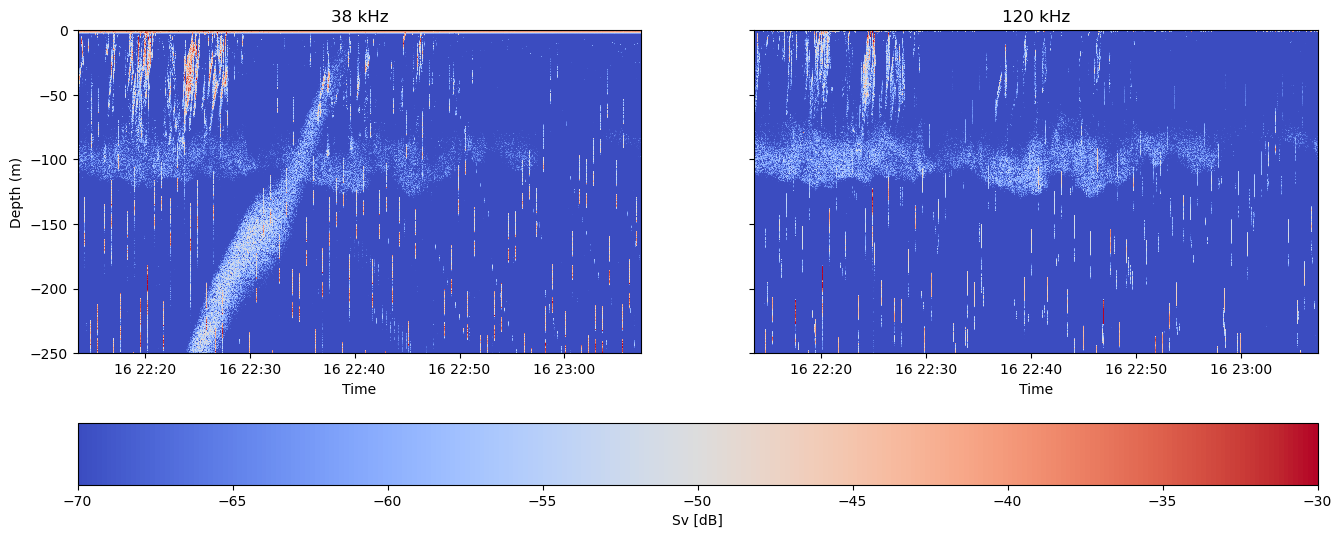

In [112]:
import matplotlib.pyplot as plt

# If xr_sv_raw is a Dataset (loaded from .nc), select the Sv variable
da_all = xr_sv_raw["Sv"] if hasattr(xr_sv_raw, "data_vars") else xr_sv_raw

freqs = da_all["frequency"].values
n = min(2, len(freqs))

fig, axes = plt.subplots(ncols=n, figsize=(8*n, 6), sharey=True)
axes = [axes] if n == 1 else axes  # ensure iterable

for i, ax in enumerate(axes):
    da = da_all.isel(frequency=i)  # (depth, time)

    im = ax.pcolormesh(
        da["time"],
        -da["depth"],
        da,
        shading="auto",
        cmap="coolwarm",
        vmin=-70,
        vmax=-30,
    )

    ax.set_title(f"{freqs[i]/1000:.0f} kHz")
    ax.set_xlabel("Time")
    if i == 0:
        ax.set_ylabel("Depth (m)")

fig.colorbar(im, ax=axes, orientation="horizontal", label="Sv [dB]")
plt.show()

What do we see here? First of all, we see impulse noise, which are the vertical lines dotted all over the images. When focusing on the 120kHz channel, which is the frequency at which krill produces a stronger echo, we see a krill swarm at ~100m depth. However, there are also some dense signals above the krill swarm, extending all the way to the surface. Let's have a closer look!

### Plot selected view

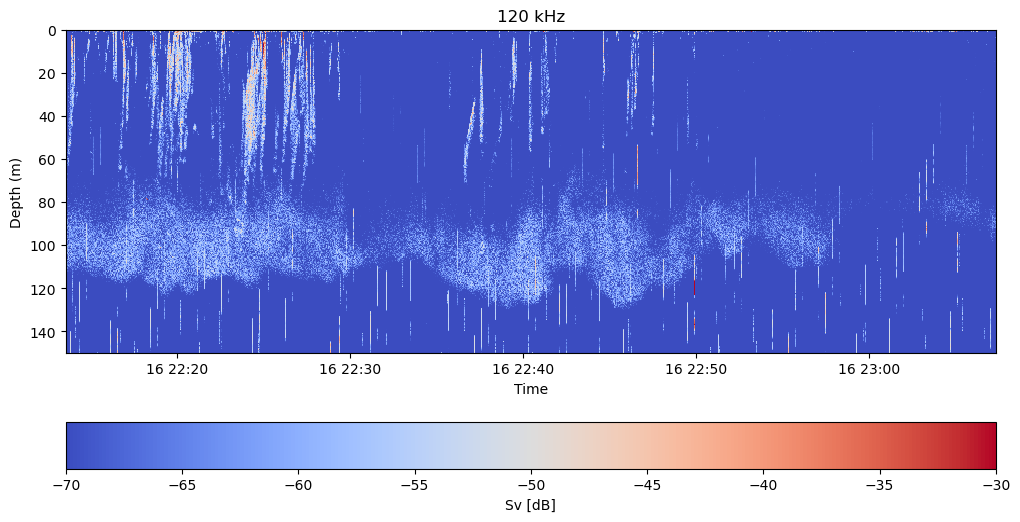

In [113]:
# If loaded from NetCDF, select the Sv variable
da_all = xr_sv_raw["Sv"] if hasattr(xr_sv_raw, "data_vars") else xr_sv_raw

# Select frequency index to plot
da = da_all.isel(frequency=i)
freq = da_all.frequency.values[i]

i = 1
# 0 → 38 kHz
# 1 → 120 kHz

da = da_all.isel(frequency=i)  # (depth, time)
freq = da_all.frequency.values[i]

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.pcolormesh(
    da.time,
    da.depth,          # positive depth
    da,
    shading="auto",
    cmap="coolwarm",
    vmin=-70,
    vmax=-30,
)

ax.set_title(f"{freq/1000:.0f} kHz")
ax.set_xlabel("Time")
ax.set_ylabel("Depth (m)")

# Optional zooms
# ax.set_xlim(pd.Timestamp("2021-07-16 22:13:36"), pd.Timestamp("2021-07-16 22:30:00"))
ax.set_ylim(0, 150)
ax.invert_yaxis()

fig.colorbar(im, ax=ax, orientation="horizontal", label="Sv [dB]")
plt.show()


These comet-like signals are actually bubble trails left by penguins or fur seals diving under the fishing vessel in pursuit of the same krill swarm (e.g. check this study (https://doi.org/10.1073/pnas.2417203122), which extracted such predator signals from the krill fisheries acoustics to track encounter dynamics between the fishing fleet and krill predators). Using this tutorial as a base to get access to the krill acoustics, you can now start your own analyses!